# Bike Sharing データの単回帰分析
本ノートブックでは、Bike Sharing データを用いて、気温 temp が利用者数 cnt に与える影響を単回帰モデルで分析し、必要に応じて2次項を加えたモデルとの比較を行う。
本分析では、pandasで読み込んだBike SharingデータをSQLiteに登録し、
SQLを用いて月別・季節別・天気別などの基本集計を行った。
その後、集計結果を確認しながら、気温と自転車利用者数の関係を単回帰モデルで分析する。

In [1]:
#数値計算に使うライブラリ
import numpy as np
import pandas as pd
from scipy import stats
#読み込んだデータを省略せずに表示させる設定
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
#表示桁数の設定
pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)
#グラフを描画するライブラリ
from matplotlib import pyplot as plt
import seaborn as sns
#グラフの日本語表記
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Meiryo'
#統計を推定するライブラリ
import statsmodels.formula.api as smf
import statsmodels.api as sm

## 1. データの確認
ここでは、データを読み込み、データの型や欠損値を確認、変数の設定を行う。

#### データの読み込み

In [2]:
bike_data = pd.read_csv('day.csv')
print(bike_data.head(3))

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   

   weathersit   temp  atemp    hum  windspeed  casual  registered   cnt  
0           2  0.344  0.364  0.806      0.160     331         654   985  
1           2  0.363  0.354  0.696      0.249     131         670   801  
2           1  0.196  0.189  0.437      0.248     120        1229  1349  


#### CSVをSQLiteに入れる

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(":memory:")
bike_data.to_sql("day", conn, index=False, if_exists="replace")

731

#### データ全体の欠損値を確認

In [4]:
print('欠損値の個数 :', bike_data.isnull().sum().sum())

欠損値の個数 : 0


#### データの型を確認

In [5]:
print(bike_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None


#### 変数の設定

In [6]:
#目的変数
target_col = 'cnt'
#説明変数の候補（連続変数）
feature_cols_numeric = ["temp", "hum", "windspeed"]
#説明変数の候補（カテゴリー変数）
feature_cols_categorical = [
    "season", "yr", "mnth", "holiday",
    "weekday", "workingday", "weathersit"
]
#外す列
drop_cols = ["instant", "dteday", "casual", "registered", "atemp"]
print('目的変数 :', target_col)
print('説明変数(連続)', feature_cols_numeric)
print('説明変数（カテゴリー型）', feature_cols_categorical)

目的変数 : cnt
説明変数(連続) ['temp', 'hum', 'windspeed']
説明変数（カテゴリー型） ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']


## 2. 基本集計と可視化
ここでは、データの平均や分散について調べる。カテゴリー型の説明変数は、カテゴリーごとに平均値を調べて、箱ひげ図を用いて可視化する。また、連続型の説明変数は散布図を確認する。

### 平均の調査

In [7]:
#全体の平均
print(bike_data.mean(numeric_only=True))

instant        366.000
season           2.497
yr               0.501
mnth             6.520
holiday          0.029
weekday          2.997
workingday       0.684
weathersit       1.395
temp             0.495
atemp            0.474
hum              0.628
windspeed        0.190
casual         848.176
registered    3656.172
cnt           4504.349
dtype: float64


### カテゴリー変数はカテゴリー別の平均を調査

#### 月別の利用者数を集計

   month  avg_temp  avg_hum  avg_windspeed   avg_cnt
0     01     0.236    0.586          0.206  2176.339
1     02     0.299    0.567          0.216  2655.298
2     03     0.391    0.588          0.223  3692.258
3     04     0.470    0.588          0.234  4484.900
4     05     0.595    0.689          0.183  5349.774
5     06     0.684    0.576          0.185  5772.367
6     07     0.755    0.598          0.166  5563.677
7     08     0.709    0.638          0.173  5664.419
8     09     0.616    0.715          0.166  5766.517
9     10     0.485    0.694          0.175  5199.226
10    11     0.369    0.625          0.184  4247.183
11    12     0.324    0.666          0.177  3403.806


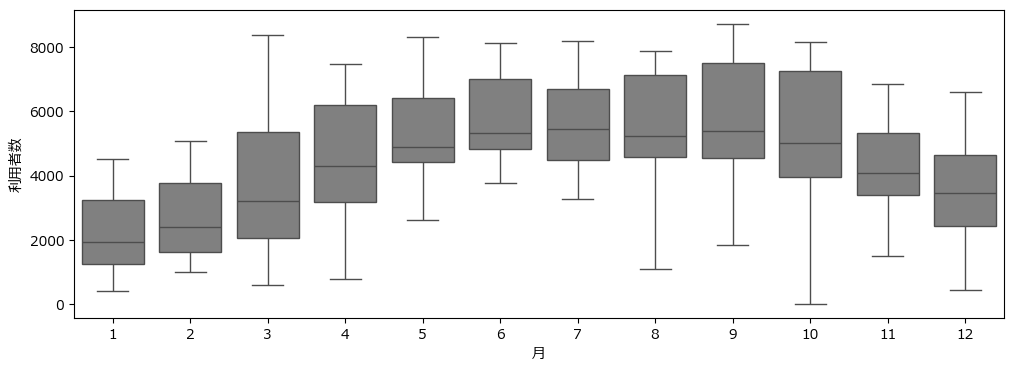

In [8]:
# SQLで集計
monthly_summary = pd.read_sql("""
SELECT 
    strftime('%m', dteday) AS month,
    AVG(temp) AS avg_temp,
    AVG(hum) AS avg_hum,
    AVG(windspeed) AS avg_windspeed,
    AVG(cnt) AS avg_cnt
FROM day
GROUP BY month
ORDER BY month
""", conn)

print(monthly_summary)

#箱ひげ図の作成
plt.figure(figsize=(12,4))
sns.boxplot(x='mnth', y='cnt', data=bike_data, color='gray')
plt.xlabel('月')
plt.ylabel('利用者数')
plt.show()

#### 季節ごとに利用者数を集計

   season  avg_temp  avg_hum  avg_windspeed   avg_cnt
0       1     0.298    0.583          0.215  2604.133
1       2     0.544    0.627          0.204  4992.332
2       3     0.706    0.633          0.172  5644.303
3       4     0.423    0.669          0.172  4728.163


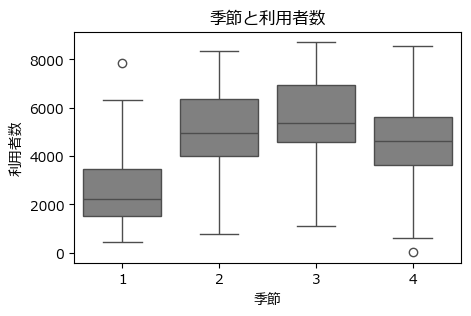

In [9]:
season_summary = pd.read_sql("""
SELECT 
    season,
    AVG(temp) AS avg_temp,
    AVG(hum) AS avg_hum,
    AVG(windspeed) AS avg_windspeed,
    AVG(cnt) AS avg_cnt
FROM day
GROUP BY season
ORDER BY season
""", conn)

print(season_summary)

#箱ひげ図の作成
plt.figure(figsize=(5,3))
sns.boxplot(x='season', y='cnt', data=bike_data, color='gray')
plt.xlabel('季節')
plt.ylabel('利用者数')
plt.title('季節と利用者数')
plt.show()

#### 休日かどうかごとに集計

   holiday  avg_temp  avg_hum  avg_windspeed   avg_cnt
0        0     0.496    0.628          0.190  4527.104
1        1     0.465    0.615          0.193  3735.000


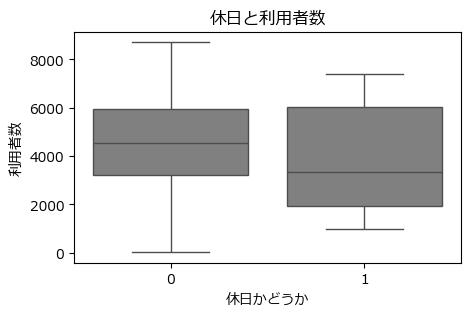

In [10]:
holiday_summary = pd.read_sql("""
SELECT 
    holiday,
    AVG(temp) AS avg_temp,
    AVG(hum) AS avg_hum,
    AVG(windspeed) AS avg_windspeed,
    AVG(cnt) AS avg_cnt
FROM day
GROUP BY holiday
ORDER BY holiday
""", conn)
print(holiday_summary)

#箱ひげ図の作成
plt.figure(figsize=(5,3))
sns.boxplot(x='holiday', y='cnt', data=bike_data, color='gray')
plt.xlabel('休日かどうか')
plt.ylabel('利用者数')
plt.title('休日と利用者数')
plt.show()

#### 天気ごとに集計

   weathersit  avg_temp  avg_hum  avg_windspeed   avg_cnt
0           1     0.512    0.566          0.190  4876.786
1           2     0.470    0.726          0.186  4035.862
2           3     0.433    0.849          0.243  1803.286


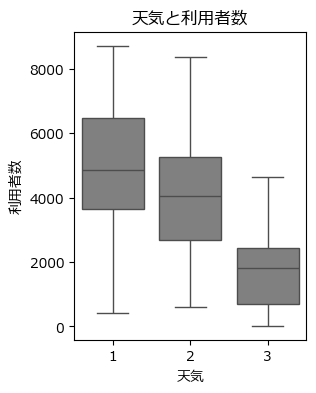

In [11]:
weather_summary = pd.read_sql("""
SELECT 
    weathersit,
    AVG(temp) AS avg_temp,
    AVG(hum) AS avg_hum,
    AVG(windspeed) AS avg_windspeed,
    AVG(cnt) AS avg_cnt
FROM day
GROUP BY weathersit
ORDER BY weathersit
""", conn)
print(weather_summary)

#箱ひげ図の作成
plt.figure(figsize=(3,4))
sns.boxplot(x='weathersit', y='cnt', data=bike_data, color='gray')
plt.xlabel('天気')
plt.ylabel('利用者数')
plt.title('天気と利用者数')
plt.show()

#### 年次ごとに集計

   year  avg_temp  avg_hum  avg_windspeed   avg_cnt
0  2011     0.487    0.644          0.191  3405.762
1  2012     0.504    0.612          0.190  5599.934


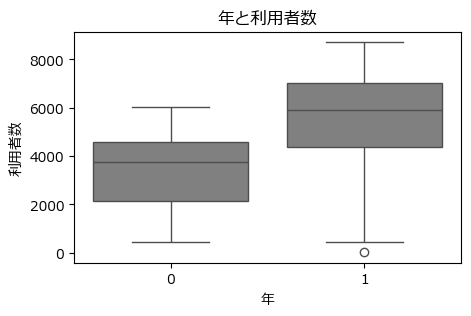

In [12]:
year_summary = pd.read_sql("""
SELECT 
    strftime('%Y', dteday) AS year,
    AVG(temp) AS avg_temp,
    AVG(hum) AS avg_hum,
    AVG(windspeed) AS avg_windspeed,
    AVG(cnt) AS avg_cnt
FROM day
GROUP BY year
ORDER BY year
""", conn)
print(year_summary)

#箱ひげ図の作成
plt.figure(figsize=(5,3))
sns.boxplot(x='yr', y='cnt', data=bike_data, color='gray')
plt.xlabel('年')
plt.ylabel('利用者数')
plt.title('年と利用者数')
plt.show()

#### 曜日ごとに集計

   weekday  avg_temp  avg_hum  avg_windspeed   avg_cnt
0        0     0.484    0.628          0.189  4228.829
1        1     0.493    0.638          0.191  4338.124
2        2     0.504    0.642          0.192  4510.663
3        3     0.505    0.645          0.188  4548.538
4        4     0.504    0.609          0.192  4667.260
5        5     0.496    0.614          0.186  4690.288
6        6     0.482    0.620          0.197  4550.543


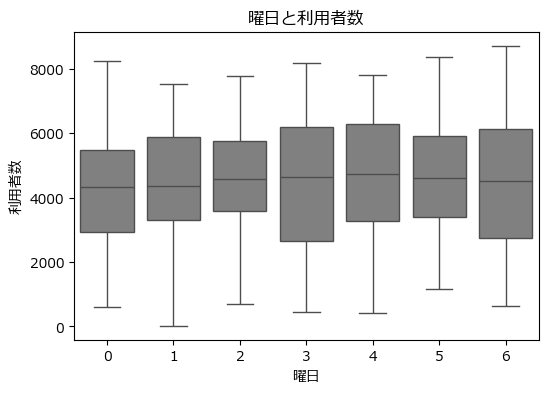

In [13]:
weekday_summary = pd.read_sql("""
SELECT
    weekday,
    AVG(temp) AS avg_temp,
    AVG(hum) AS avg_hum,
    AVG(windspeed) AS avg_windspeed,
    AVG(cnt) AS avg_cnt
FROM day
GROUP BY weekday
ORDER BY weekday
""", conn)
print(weekday_summary)

#箱ひげ図の作成
plt.figure(figsize=(6, 4))
sns.boxplot(x='weekday', y='cnt', data=bike_data, color='gray')
plt.xlabel('曜日')
plt.ylabel('利用者数')
plt.title('曜日と利用者数')
plt.show()

#### 勤務日ごとに集計

   workingday  avg_temp  avg_hum  avg_windspeed   avg_cnt
0           0     0.481    0.623          0.193  4330.169
1           1     0.502    0.630          0.189  4584.820


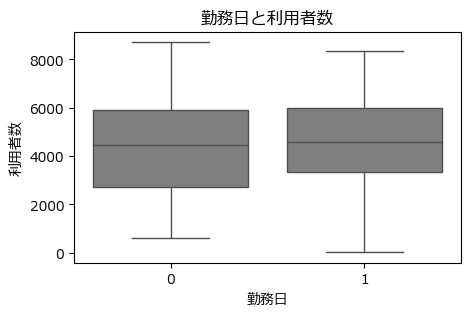

In [14]:
workingday_summary = pd.read_sql("""
SELECT
    workingday,
    AVG(temp) AS avg_temp,
    AVG(hum) AS avg_hum,
    AVG(windspeed) AS avg_windspeed,
    AVG(cnt) AS avg_cnt
FROM day
GROUP BY workingday
ORDER BY workingday
""", conn)
print(workingday_summary)

#箱ひげ図の作成
plt.figure(figsize=(5, 3))
sns.boxplot(x='workingday', y='cnt', data=bike_data, color='gray')
plt.xlabel('勤務日')
plt.ylabel('利用者数')
plt.title('勤務日と利用者数')
plt.show()

### 考察メモ
##### 季節・月について
箱ひげ図と平均値を見ると、利用者数は夏に高く、冬に低い傾向がみられる。  
このことから、気温が高い時期ほど利用者数が増える可能性がある。
##### 曜日について
曜日ごとの平均値を比較すると、大きな差や明確な増減の傾向は確認しにくい。
##### 勤務日について
勤務日かどうかで比較しても、平均値に大きな差は見られない。
このため、勤務日だけでは利用者数の違いを十分に説明できない可能性がある。

#### 連続型の説明変数は散布図を確認する。

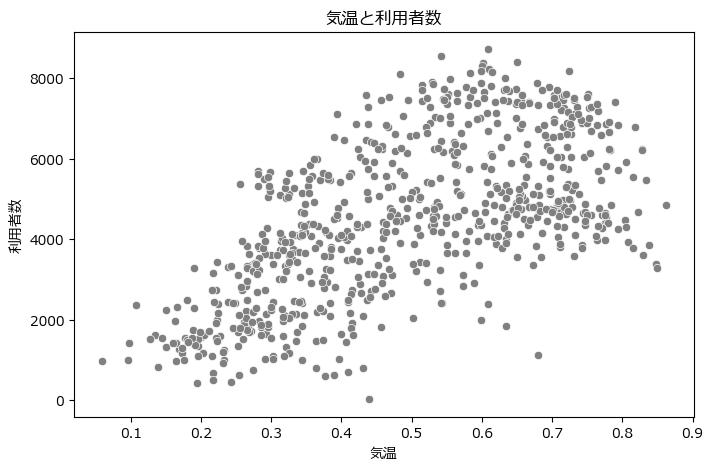

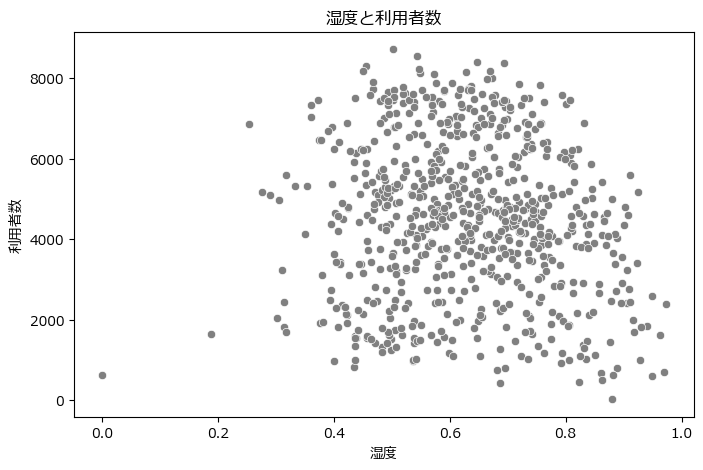

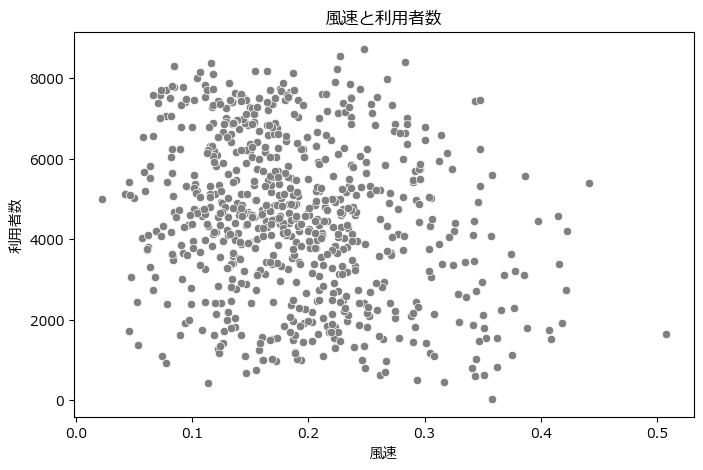

In [15]:
#気温と利用者数の間の散布図
plt.figure(figsize=(8, 5))
sns.scatterplot(x='temp', y='cnt', data=bike_data, color='gray')
plt.xlabel('気温')
plt.ylabel('利用者数')
plt.title('気温と利用者数')
plt.show()

#湿度と利用者数の間の散布図
plt.figure(figsize=(8, 5))
sns.scatterplot(x='hum', y='cnt', data=bike_data, color='gray')
plt.xlabel('湿度')
plt.ylabel('利用者数')
plt.title('湿度と利用者数')
plt.show()

#風速と利用者数の散布図
plt.figure(figsize=(8, 5))
sns.scatterplot(x='windspeed', y='cnt', data=bike_data, color='gray')
plt.xlabel('風速')
plt.ylabel('利用者数')
plt.title('風速と利用者数')
plt.show()

### 考察
##### 気温と利用者数について
気温と利用者数の間には正の相関の傾向が示唆される。これは先ほどの平均値で見た季節と月の結果と対応があると考えられる
##### 湿度と利用者数について
湿度が高くなるほど利用者数が少なくなる傾向がみられ、湿度と利用者数の間には負の相関が示唆される。
##### 風速と利用者数について  
 風速が大きくなるほど利用者数が少なくなる傾向がみられ、負の相関が示唆される。

#### ヒストグラムの確認

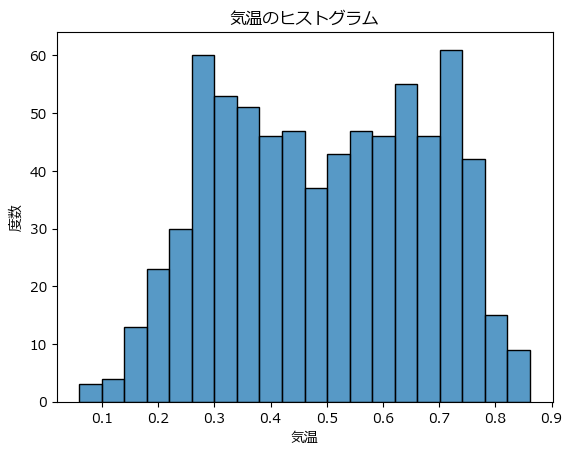

In [16]:
sns.histplot(x='temp', data=bike_data, bins=20)
plt.xlabel('気温')
plt.ylabel('度数')
plt.title('気温のヒストグラム')
plt.show()

array([[<Axes: title={'center': 'cnt'}>,
        <Axes: title={'center': 'temp'}>],
       [<Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'hum'}>],
       [<Axes: title={'center': 'windspeed'}>, <Axes: >]], dtype=object)

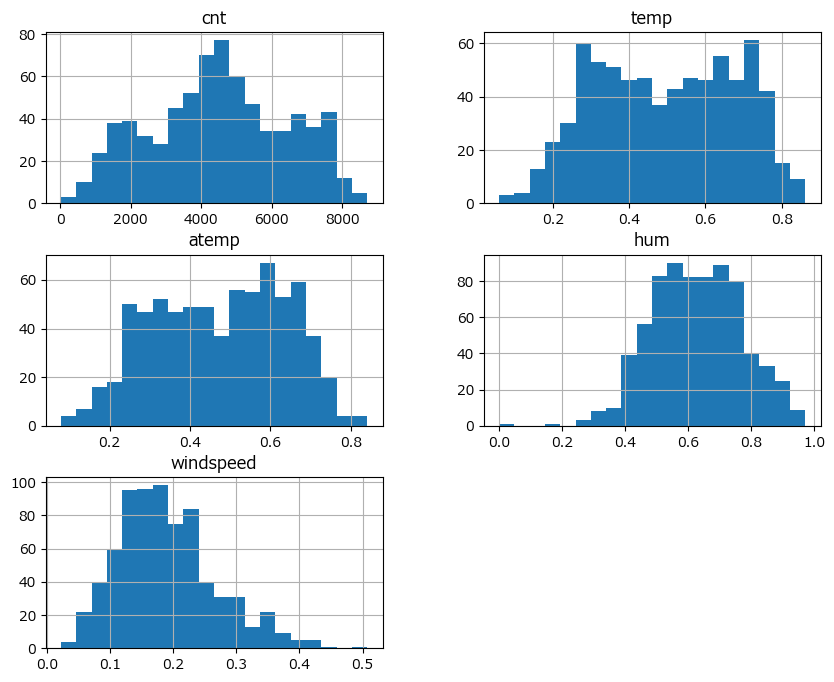

In [17]:
bike_data[['cnt', 'temp', 'atemp', 'hum', 'windspeed']].hist(figsize=(10, 8), bins=20)

#### 相関関係を調査

##### 相関関係の数値列を取り出す

In [18]:
bike_data.corr(numeric_only=True)

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000e+00,0.412,0.866,0.497,0.016,-1.618e-05,-0.004,-0.021,1.506e-01,0.153,0.016,-0.113,0.275,0.660,0.629
season,4.122e-01,1.000,-0.002,0.831,-0.011,-3.080e-03,0.012,0.019,3.343e-01,0.343,0.205,-0.229,0.210,0.412,0.406
yr,8.660e-01,-0.002,1.000,-0.002,0.008,-5.461e-03,-0.002,-0.049,4.760e-02,0.046,-0.111,-0.012,0.249,0.594,0.567
mnth,4.967e-01,0.831,-0.002,1.000,0.019,9.509e-03,-0.006,0.044,2.202e-01,0.227,0.222,-0.208,0.123,0.293,0.280
holiday,1.614e-02,-0.011,0.008,0.019,1.000,-1.020e-01,-0.253,-0.035,-2.856e-02,-0.033,-0.016,0.006,0.054,-0.109,-0.068
weekday,-1.618e-05,-0.003,-0.005,0.010,-0.102,1.000e+00,0.036,0.031,-1.700e-04,-0.008,-0.052,0.014,0.060,0.057,0.067
workingday,-4.337e-03,0.012,-0.002,-0.006,-0.253,3.579e-02,1.000,0.061,5.266e-02,0.052,0.024,-0.019,-0.518,0.304,0.061
weathersit,-2.148e-02,0.019,-0.049,0.044,-0.035,3.109e-02,0.061,1.000,-1.206e-01,-0.122,0.591,0.040,-0.247,-0.260,-0.297
temp,1.506e-01,0.334,0.048,0.220,-0.029,-1.700e-04,0.053,-0.121,1.000e+00,0.992,0.127,-0.158,0.543,0.540,0.627
atemp,1.526e-01,0.343,0.046,0.227,-0.033,-7.537e-03,0.052,-0.122,9.917e-01,1.000,0.140,-0.184,0.544,0.544,0.631


In [19]:
bike_data.corr(numeric_only=True)["cnt"].sort_values(ascending=False)

cnt           1.000
registered    0.946
casual        0.673
atemp         0.631
instant       0.629
temp          0.627
yr            0.567
season        0.406
mnth          0.280
weekday       0.067
workingday    0.061
holiday      -0.068
hum          -0.101
windspeed    -0.235
weathersit   -0.297
Name: cnt, dtype: float64

#### 相関関係のヒートマップ

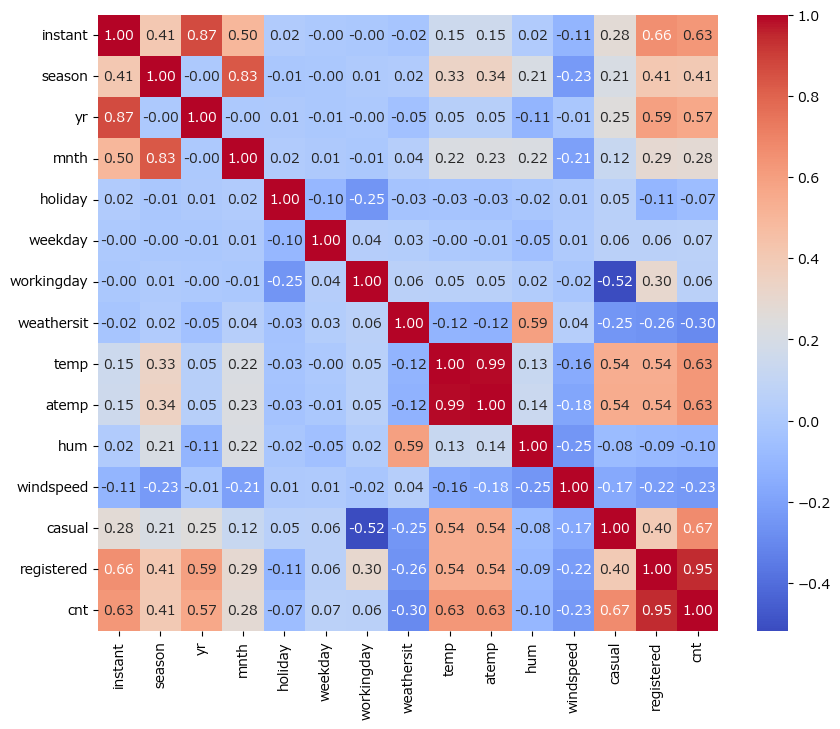

In [20]:
corr = bike_data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

### 考察  
相関関係を表すヒートマップを確認すると、気温と利用者数の間には正の相関がみられた。これは、先に散布図から確認した傾向とも一致している。
一方で、湿度と利用者数の間には負の相関が、風速と利用者数の間には弱い負の相関がみられ、気象条件が利用者数に影響している可能性が示唆される。そこで、まずは気温を説明変数、利用者数を目的変数として、単回帰モデルの構築を試みる。

## 3. 単回帰分析の実行(cnt~temp)
ここでは、cnt~tempの単回帰を構築して評価をする。

#### モデル用データをSQLで作る

In [21]:
model_df = pd.read_sql("""
SELECT
    cnt,
    temp,
    hum,
    windspeed,
    season,
    weathersit,
    weekday,
    workingday,
    yr,
    mnth
FROM day
""", conn)

model_df.head()

,cnt,temp,hum,windspeed,season,weathersit,weekday,workingday,yr,mnth
0,985,0.344,0.806,0.160,1,2,6,0,0,1
1,801,0.363,0.696,0.249,1,2,0,0,0,1
2,1349,0.196,0.437,0.248,1,1,1,1,0,1
3,1562,0.200,0.590,0.160,1,1,2,1,0,1
4,1600,0.227,0.437,0.187,1,1,3,1,0,1


#### cntとtempで単回帰を構築

In [22]:
lm_model1 = smf.ols('cnt ~ temp', data=model_df).fit()
lm_model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     473.5
Date:                Thu, 21 May 2026   Prob (F-statistic):           2.81e-81
Time:                        20:32:36   Log-Likelihood:                -6386.8
No. Observations:                 731   AIC:                         1.278e+04
Df Residuals:                     729   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1214.6421    161.164      7.537      0.000     898.242    1531.042
temp        6640.7100    305.188     21.759      0.000    6041.558    7239.862
==============================================================================
Omnibus:                       20.477   Durbin-Watson:                   0.468
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.566
Skew:                           0.167   Prob(JB):                      0.00187
Kurtosis:                       2.452   Cond. No.                         6.85
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 構築した単回帰モデルを検証

##### 出力結果の要点整理

In [23]:
print('tempの係数 :', round(lm_model1.params['temp'], 3))
print(f"p値 : {lm_model1.pvalues['temp']:.3e}")
print('決定係数R^2 :', round(lm_model1.rsquared,3))
print('調整済み決定係数 :', round(lm_model1.rsquared_adj, 3))

tempの係数 : 6640.71
p値 : 2.811e-81
決定係数R^2 : 0.394
調整済み決定係数 : 0.393


##### 散布図に回帰直線を重ねる

<Figure size 800x500 with 0 Axes>

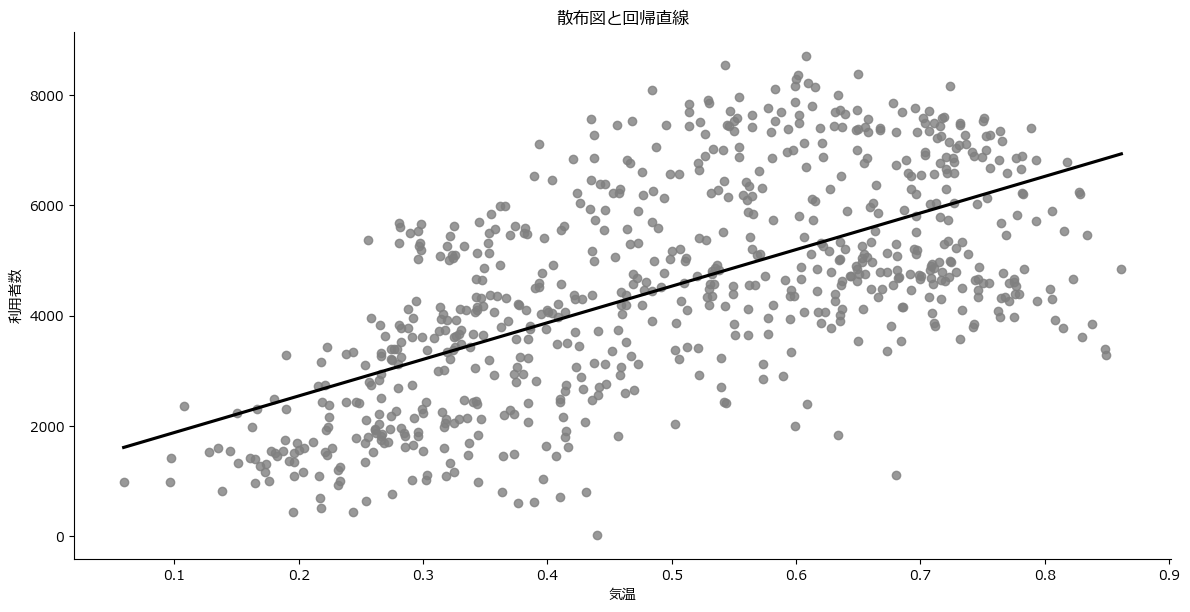

In [24]:
plt.figure(figsize=(8, 5))
sns.lmplot(x='temp', y='cnt', data=model_df, scatter_kws={'color':'gray'},
          line_kws={'color':'black'}, ci=None, height=6, aspect=2)
plt.xlabel('気温')
plt.ylabel('利用者数')
plt.title('散布図と回帰直線')
plt.show()

### 考察
・tempの係数が正であることから、気温が上がると利用者数が増加する傾向があると分かる\
・p値が0に近いことから、temp は利用者数に対して統計的に有意な説明変数であるといえる。\
・調整済みの決定係数が0.394であるため、気温だけでデータの約40%が説明される。\
・ただし、残りの約60%は他の要因によって説明される可能性がある。

## 4. 残差診断
ここでは、残差診断をして、先ほどの単回帰モデルを評価する。

#### 残差の確認

In [25]:
#残差
resid = lm_model1.resid
#当てはめ値
fitted = lm_model1.fittedvalues
print('残差 :')
print(round(resid.head(3), 3))
print('当てはめ値 :')
print(round(fitted.head(3),3))

残差 :
0   -2515.155
1   -2827.394
2   -1169.638
dtype: float64
当てはめ値 :
0    3500.155
1    3628.394
2    2518.638
dtype: float64


#### 残差と予測値の比較

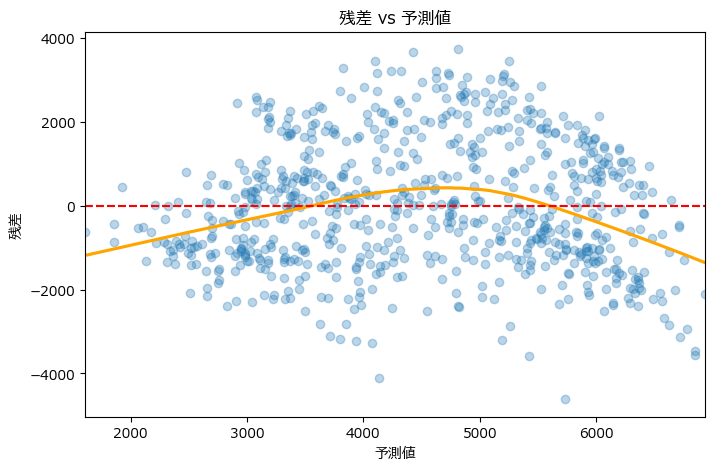

In [26]:
#図の作成
plt.figure(figsize=(8, 5))
sns.residplot(x=fitted, y=resid, lowess=True, scatter_kws={'alpha':0.3}, line_kws={'color': 'orange'}) #残差プロットの点全体の傾向を、なめらかな1本の曲線で見やすくしたもの
plt.axhline(0, color='red', linestyle='--')

plt.xlabel('予測値')
plt.ylabel('残差')
plt.title('残差 vs 予測値')
plt.show()

### 考察
残差と予測値の関係を見ると、残差の傾向を表すLOWESS線が山なりに曲がっている。大きな破綻があるとはいえないが、直線からやや外れており、単純な線形関係だけでは捉えきれていない可能性がある。そこで、この曲がりを改善するために、2次項をモデルに組み込むことを検討する。

## 5. 2次項を含むモデルと単回帰の比較
ここでは、2次項temp^2を組み込んだモデルを構築して、先ほどのtempのみを説明変数とする単回帰モデルと比較する。

#### 2次項を組み込んだモデル

In [27]:
lm_model2 = smf.ols('cnt ~ temp + I(temp**2)', data=model_df).fit()
lm_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     301.7
Date:                Thu, 21 May 2026   Prob (F-statistic):           3.76e-96
Time:                        20:32:37   Log-Likelihood:                -6349.1
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     728   BIC:                         1.272e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -1901.9557    382.391     -4.974      0.000   -2652.676   -1151.236
temp          2.141e+04   1685.202     12.703      0.000    1.81e+04    2.47e+04
I(temp ** 2) -1.506e+04   1692.522     -8.895      0.000   -1.84e+04   -1.17e+04
==============================================================================
Omnibus:                       13.158   Durbin-Watson:                   0.546
Prob(Omnibus):                  0.001   Jarque-Bera (JB):                7.781
Skew:                          -0.044   Prob(JB):                       0.0204
Kurtosis:                       2.502   Cond. No.                         52.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 2次項ありの残差図

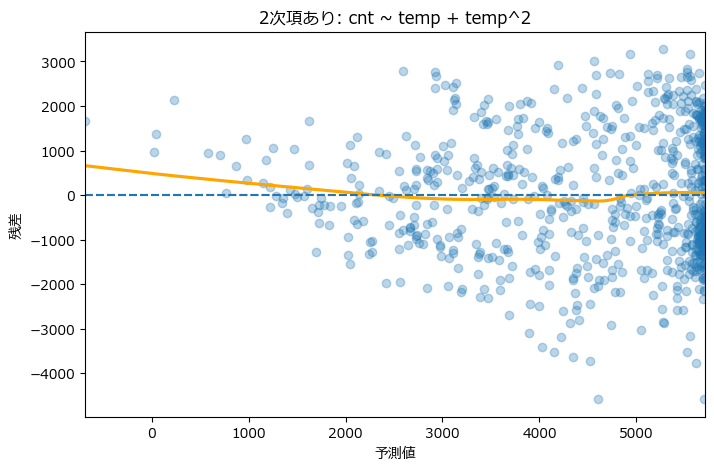

In [28]:
plt.figure(figsize=(8, 5))
sns.residplot(x=lm_model2.fittedvalues, y=lm_model2.resid, lowess=True, scatter_kws={"alpha":0.3}, line_kws={"color":"orange"})
plt.axhline(0, linestyle='--')
plt.xlabel('予測値')
plt.ylabel('残差')
plt.title('2次項あり: cnt ~ temp + temp^2')
plt.show()

### 考察
2次項 temp^2 をモデルに組み込むことで、LOWESS線はより 0 付近に近づき、一次モデルで見られた山なりの傾向は弱くなった。したがって、temp と cnt の関係は、一次式だけでなく2次の関係も考慮したほうが適切である可能性がある。
一方で、散布図の点は右側に偏っており、左側の観測値が少ないため、その部分ではLOWESS線がやや不安定に見える。そこで、この偏りが予測値の分布による自然なものかを確認するために、cnt ~ temp + temp^2 モデルの予測値の分布を調べる。

#### cnt~temp + temp^2の予測値の分布

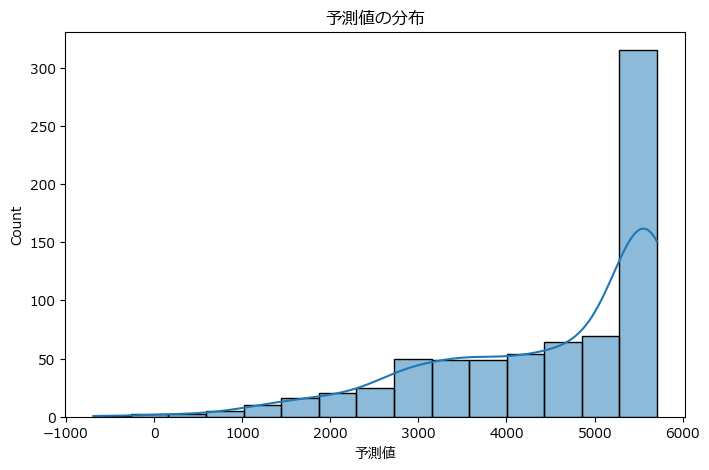

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(lm_model2.fittedvalues, kde=True)
plt.xlabel('予測値')
plt.title('予測値の分布')
plt.show()

### 考察
cnt ~ temp + temp^2 の予測値の分布を確認すると、値は右側にやや偏って分布していることが分かる。

#### lm_model2の出力結果の要点

In [30]:
print('tempの係数 :', round(lm_model2.params['temp'], 3))
print('temp^2の係数 :',round(lm_model2.params['I(temp ** 2)'],3))
print(f"tempのp値 : {lm_model2.pvalues['temp']:.3e}")
print(f"temp^2のp値 : {lm_model2.pvalues['I(temp ** 2)']:.3e}")
print('決定係数R^2 :', round(lm_model2.rsquared,3))
print('調整済み決定係数 :', round(lm_model2.rsquared_adj, 3))

tempの係数 : 21406.931
temp^2の係数 : -15055.025
tempのp値 : 1.548e-33
temp^2のp値 : 4.569e-18
決定係数R^2 : 0.453
調整済み決定係数 : 0.452


### 考察
2次項を入れたモデルでは、temp の係数は 21406.931、temp^2 の係数は -15055.025 であった。temp^2 の係数が負であることから、気温が利用者数に与える影響は単純な直線関係ではなく、ある程度までは増加するが、その増え方は次第に緩やかになる可能性が示唆される。また、調整済み決定係数は 0.453 であり、temp のみを用いたモデルの 0.394 より高いため、2次項を含むモデルのほうがデータをよりよく説明していると考えられる。\
さらに、この2つのモデルについては、AICを用いて比較し、モデルの適切さを追加で検討する。

#### AICによるモデル評価

In [31]:
null_model = smf.ols(formula='cnt ~ 1', data=model_df).fit()
print('NullモデルのAIC :', round(null_model.aic, 3))
print('cnt~tempのAIC :', round(lm_model1.aic, 3))
print('cnt~temp+temp^2のAIC :', round(lm_model2.aic, 3))

NullモデルのAIC : 13141.373
cnt~tempのAIC : 12777.536
cnt~temp+temp^2のAIC : 12704.116


### 考察
AICを用いてモデル比較を行ったところ、
Nullモデルは 13141.373、単回帰モデル cnt ~ temp は 12777.536、
2次項を加えたモデル cnt ~ temp + temp^2 は 12704.116 であった。
AICは小さいほど良いので、3つの中では cnt ~ temp + temp^2 が最も適切と判断される。
特に、cnt ~ temp からさらに約73低下しており、温度と利用者数の関係を直線だけでなく曲線で表す意義が大きいことが示唆される。\
ただし、AICだけではモデルの妥当性を十分に判断できないため、次にQ-Q plotを用いて残差の正規性を確認する。

#### Q-Q plotの確認

<Figure size 800x500 with 0 Axes>

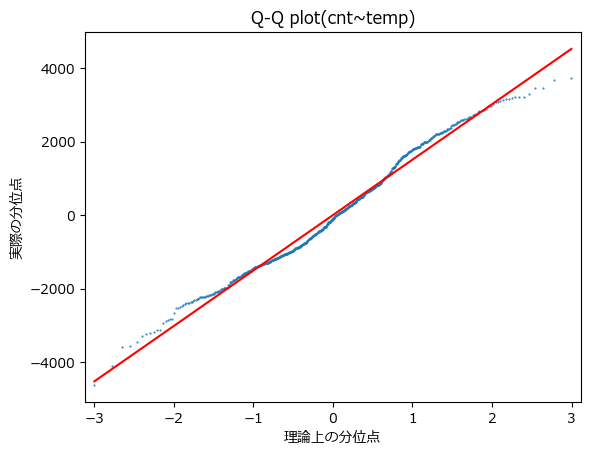

<Figure size 800x500 with 0 Axes>

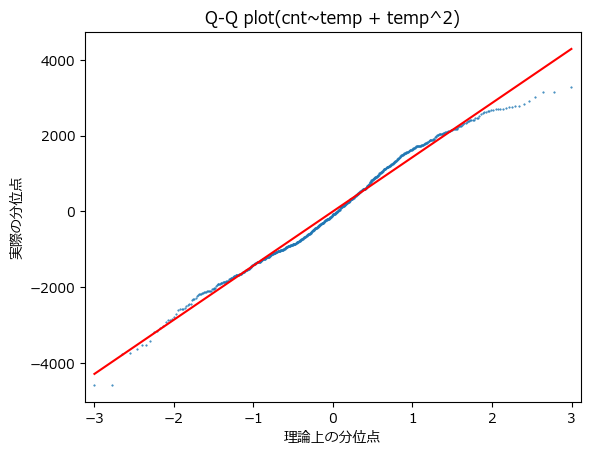

In [32]:
e_1 = lm_model1.resid   #lm_model1の残差
e_2 = lm_model2.resid   #lm_model2の残差

#Q-Q plot(cnt~temp)
plt.figure(figsize=(8, 5))
fig_1 = sm.qqplot(e_1, line='s', marker='.', markersize=1)
plt.xlabel('理論上の分位点')
plt.ylabel('実際の分位点')
plt.title('Q-Q plot(cnt~temp)')
plt.show()

#Q-Q plot(cnt~temp + temp^2)
plt.figure(figsize=(8, 5))
fig_2 = sm.qqplot(e_2, line='s', marker='.', markersize=1)
plt.xlabel('理論上の分位点')
plt.ylabel('実際の分位点')
plt.title('Q-Q plot(cnt~temp + temp^2)')
plt.show()

### 考察
Q-Q plot を確認すると、2次項を入れたモデルのほうが、点が正規直線の周辺により集まっていることが分かる。差は大きくないものの、残差の正規性という点では、2次項を加えたモデルのほうがわずかに良いと考えられる。

#### 等分散性(Scale-Location Plot)の確認

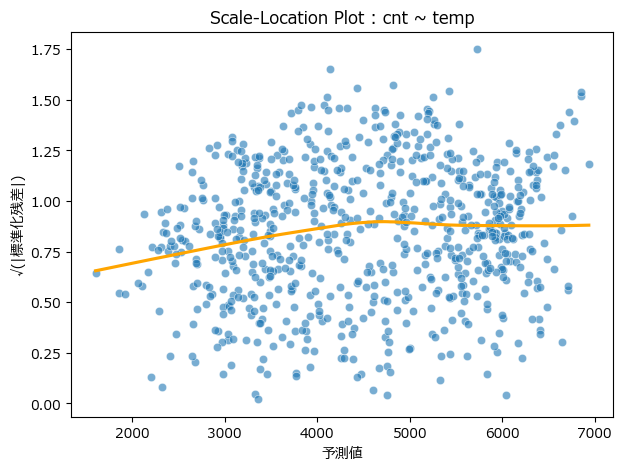

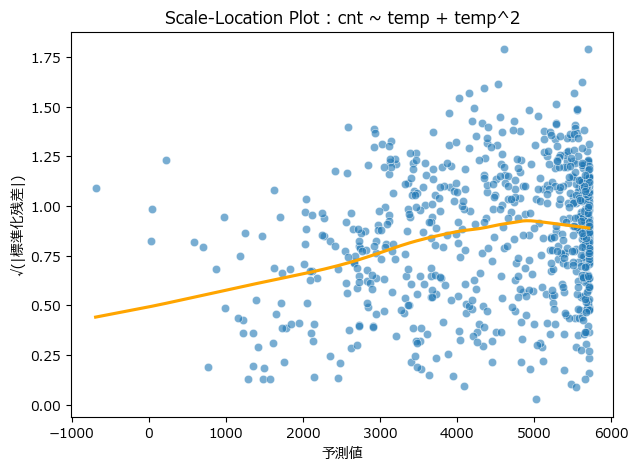

In [33]:
# model1: cnt ~ temp
fitted1 = lm_model1.fittedvalues #当てはめ値
std_resid1 = lm_model1.get_influence().resid_studentized_internal  #内部標準化残差
scale_loc_y1 = np.sqrt(np.abs(std_resid1)) #縦軸

plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted1, y=scale_loc_y1, alpha=0.6)
sns.regplot(x=fitted1, y=scale_loc_y1, scatter=False, lowess=True,
            line_kws={'color': 'orange'})
plt.xlabel('予測値')
plt.ylabel('√(|標準化残差|)')
plt.title('Scale-Location Plot : cnt ~ temp')
plt.show()


# model2: cnt ~ temp + temp^2
fitted2 = lm_model2.fittedvalues #当てはめ値
std_resid2 = lm_model2.get_influence().resid_studentized_internal #内部標準化残差
scale_loc_y2 = np.sqrt(np.abs(std_resid2)) #縦軸

plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted2, y=scale_loc_y2, alpha=0.6)
sns.regplot(x=fitted2, y=scale_loc_y2, scatter=False, lowess=True,
            line_kws={'color': 'orange'})
plt.xlabel('予測値')
plt.ylabel('√(|標準化残差|)')
plt.title('Scale-Location Plot : cnt ~ temp + temp^2')
plt.show()

### 考察
Scale-Location Plot を確認すると、2次項を組み込んだモデルでは LOWESS線の傾きがやや大きくなっていた。
一方で、図を概観する限り、y軸方向の点の散らばりは temp のみのモデルと比べて大きくは変わらなかった。
したがって、2次項を加えたことで等分散性が明確に改善したとは言いにくい。
ただし、この図は主に等分散性を確認するためのものであり、横方向の偏りや LOWESS線だけを根拠に、temp のみのモデルの当てはまりが良いと結論づけることはできない。

# 6. 結論
以上の分析から、AIC・残差プロット・Q-Q plot を総合的にみて、今回は cnt ~ temp + temp^2 を採用する。
特に、一次モデルで見られた曲線的な残差傾向が2次項の導入によって弱まり、当てはまりが改善したことを重視した。\
今後の課題としては、湿度・風速・季節など他の変数も加えた重回帰分析を行い、利用者数の変動をより高精度に説明できるかを検討したい。